<a href="https://colab.research.google.com/github/AlessandroCaforio/Python-for-ML-and-Econometrics/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression
This notebook will be one of the most important in the entire folder. Linear regression is the foundational method used across virtually the entire scientific spectrum: from physics to economics, from biostatistics to epidemiology. It is, in many ways, the gravity of quantitative reasoning — everything orbits around it at some point.
The difficulty of this method does not lie in the concept itself. As a civilization, we have understood lines for quite a while, and as students since middle school — at least in Italy, somewhere between the ages of 10 and 12. A line through a cloud of points is not a hard idea to grasp.
What is genuinely fascinating is that different disciplines arrive at the exact same method through entirely different doors. To an algebraist, linear regression is a projection problem — finding the closest point in a subspace. To a statistician, it is a probabilistic model with assumptions about noise. To an engineer or computer scientist, it is an optimization problem — minimizing a loss function. Three completely different intellectual journeys, one destination.
This has fascinated me since the first time I encountered it. The fact that a single equation can be derived from such different first principles is, I think, one of the most elegant things in all of quantitative science.

# The Algebraic Approach

The algebraic approach treats linear regression as a pure geometric/linear algebra problem: **find the vector in the column space of $X$ that is closest to $y$**.

---

## Setup

We have $n$ observations and $k$ predictors. Stack them:

$$\mathbf{y} = \begin{pmatrix} y_1 \\ \vdots \\ y_n \end{pmatrix} \in \mathbb{R}^n, \qquad \mathbf{X} = \begin{pmatrix} 1 & x_{11} & \cdots & x_{1k} \\ \vdots & \vdots & & \vdots \\ 1 & x_{n1} & \cdots & x_{nk} \end{pmatrix} \in \mathbb{R}^{n \times (k+1)}$$

We want $\boldsymbol{\beta} \in \mathbb{R}^{k+1}$ such that $\mathbf{X}\boldsymbol{\beta} \approx \mathbf{y}$.

---

## The Geometric Core

The fitted values $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$ live in the **column space** of $\mathbf{X}$:

$$\mathcal{C}(\mathbf{X}) = \{ \mathbf{X}\boldsymbol{\beta} : \boldsymbol{\beta} \in \mathbb{R}^{k+1} \}$$

which is a $(k+1)$-dimensional subspace of $\mathbb{R}^n$. In general $\mathbf{y} \notin \mathcal{C}(\mathbf{X})$ — we have more observations than parameters — so the system $\mathbf{X}\boldsymbol{\beta} = \mathbf{y}$ is overdetermined and has no exact solution.

**The algebraic criterion:** find $\hat{\boldsymbol{\beta}}$ such that the residual vector

$$\mathbf{e} = \mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}$$

is **orthogonal to every column of $\mathbf{X}$**, i.e. orthogonal to $\mathcal{C}(\mathbf{X})$.

This is simply the orthogonal projection of $\mathbf{y}$ onto $\mathcal{C}(\mathbf{X})$. This approach does not require any assumption about the datagenerating process or anything else.

---

## Derivation: The Normal Equations

The orthogonality condition is:

$$\mathbf{X}^\top \mathbf{e} = \mathbf{0}$$

This steams from analytical geometry, where orthogonality means that two vectors have an angle of 90 grades, resulting in a cosine equal to zero, meaning that the dot product (the inner product) is actually zero.

Substituting the definition of $\mathbf{e}$:

$$\mathbf{X}^\top (\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}) = \mathbf{0}$$

$$\mathbf{X}^\top \mathbf{y} - \mathbf{X}^\top \mathbf{X} \hat{\boldsymbol{\beta}} = \mathbf{0}$$

$$\boxed{\mathbf{X}^\top \mathbf{X} \hat{\boldsymbol{\beta}} = \mathbf{X}^\top \mathbf{y}}$$

These are the **normal equations**. If $\mathbf{X}$ has full column rank — i.e. $\text{rank}(\mathbf{X}) = k+1$, which requires $n \geq k+1$ and no perfect multicollinearity — then $\mathbf{X}^\top \mathbf{X}$ is symmetric positive definite and hence invertible. Therefore:

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}}$$

---

## The Projection Matrix

Define the **hat matrix** (projection matrix onto $\mathcal{C}(\mathbf{X})$):

$$\mathbf{H} = \mathbf{X}(\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top$$

Then $\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}$ and $\mathbf{e} = (\mathbf{I} - \mathbf{H})\mathbf{y}$.

**$\mathbf{H}$ is a proper orthogonal projector.** Verify:

1. **Symmetry:** $\mathbf{H}^\top = \mathbf{H}$
2. **Idempotency:** $\mathbf{H}^2 = \mathbf{X}(\mathbf{X}^\top \mathbf{X})^{-1}\underbrace{\mathbf{X}^\top \mathbf{X}(\mathbf{X}^\top \mathbf{X})^{-1}}_{= \mathbf{I}}\mathbf{X}^\top = \mathbf{H}$

And $\mathbf{M} = \mathbf{I} - \mathbf{H}$ is the **annihilator** (projects onto $\mathcal{C}(\mathbf{X})^\perp$): also symmetric and idempotent, with $\mathbf{M}\mathbf{X} = \mathbf{0}$.

---

## Orthogonal Decomposition of $\mathbf{y}$

The Pythagorean decomposition follows directly:

$$\mathbf{y} = \underbrace{\mathbf{H}\mathbf{y}}_{\hat{\mathbf{y}} \,\in\, \mathcal{C}(\mathbf{X})} + \underbrace{\mathbf{M}\mathbf{y}}_{\mathbf{e} \,\perp\, \mathcal{C}(\mathbf{X})}$$

and because the two components are orthogonal:

$$\|\mathbf{y}\|^2 = \|\hat{\mathbf{y}}\|^2 + \|\mathbf{e}\|^2$$

In centered form — subtracting $\bar{y}\mathbf{1}$ from both sides — this is exactly the **SST = SSR + SSE** decomposition, from which $R^2 = \text{SSR}/\text{SST}$ follows immediately as the squared cosine of the angle between $\mathbf{y} - \bar{y}\mathbf{1}$ and $\hat{\mathbf{y}} - \bar{y}\mathbf{1}$.

---

## What This Approach Assumes

| Assumption | Required? |
|---|---|
| Linearity: $\mathbb{E}[\mathbf{y}] = \mathbf{X}\boldsymbol{\beta}$ | No — $\boldsymbol{\beta}$ is just a vector, no DGP |
| Full column rank of $\mathbf{X}$ | **Yes** — for $(\mathbf{X}^\top\mathbf{X})^{-1}$ to exist |
| Homoskedasticity / no autocorrelation | No |
| Normality of errors | No |
| Any probabilistic structure | **No** |

This is the key distinction: $\hat{\boldsymbol{\beta}}$ here is nothing more than the **unique solution to an orthogonal projection problem**. The Gauss-Markov theorem, BLUE property, and hypothesis testing all require the probabilistic layer — which belongs to the next approach.

In [5]:
import numpy as np
rng = np.random.default_rng(seed = 42)
m = 800
X = 2 * rng.random((m,1))
y = 4 + 3 * X + rng.standard_normal((m,1))

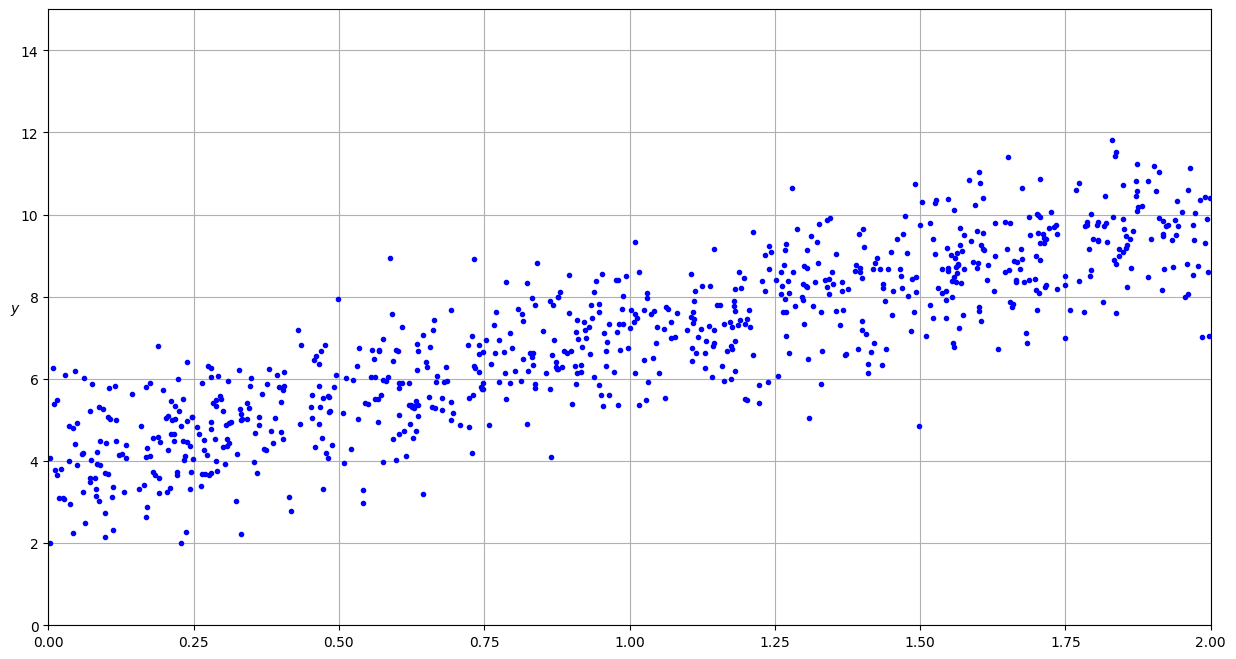

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize= (15, 8))
plt.plot(X, y, "b.")
plt.ylabel("$y$", rotation = 0)
plt.axis([0,2,0,15])
plt.grid()


plt.show()

In [7]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) #This add x0 = 1 to each instances basically it ads a column vector of 1
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y ## Where .inv is the ^{-1} and @ is the matrix product.
theta

array([[3.94676968],
       [3.029748  ]])

In [8]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta
y_predict

array([[ 3.94676968],
       [10.00626567]])

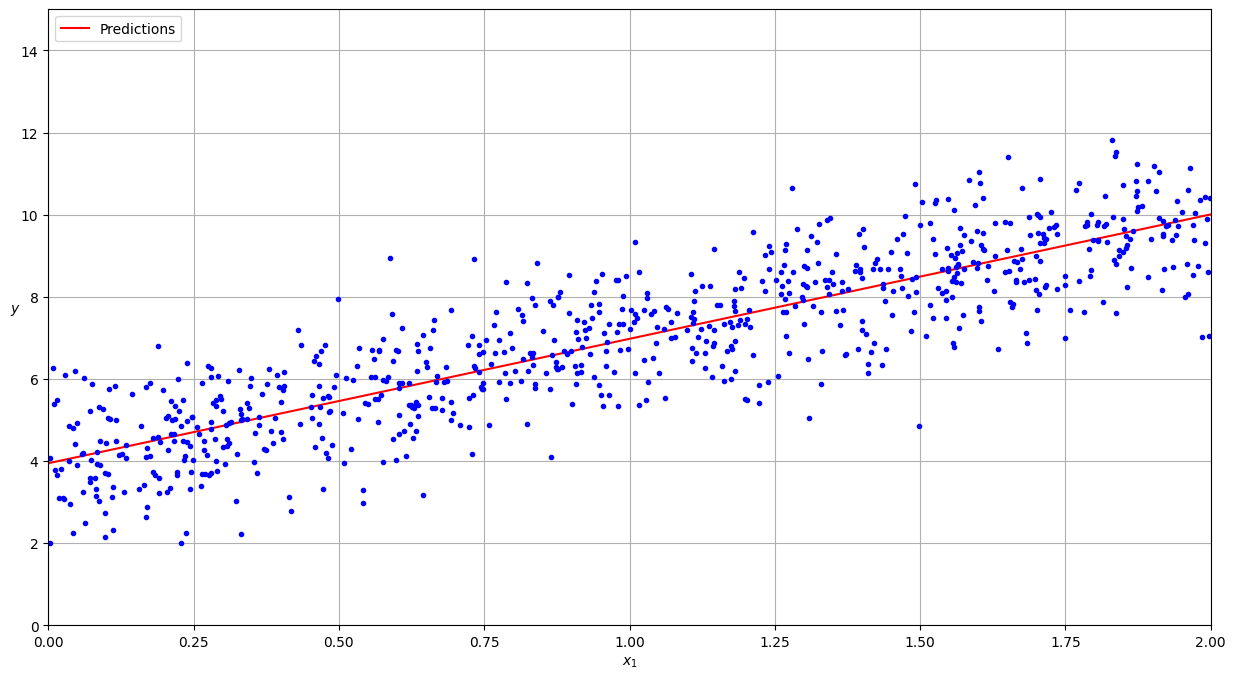

In [9]:
plt.figure(figsize = (15, 8))
plt.plot(X_new, y_predict, "r-", label = "Predictions")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation = 0)
plt.axis ([0,2, 0, 15])
plt.grid()
plt.legend(loc = "upper left")

plt.show()

In [10]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X , y)
lin_reg.intercept_, lin_reg.coef_

(array([3.94676968]), array([[3.029748]]))

Trying to use real data now, let's load up the Boston housing DataSet.

In [11]:
import pandas as pd

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt',
sep='\t',
usecols=columns)
df.head()
print(df['Central Air'].unique())


['Y' 'N']


In [12]:
# Pulizia definitiva del dataset
print("Shape iniziale:", df.shape)

# 1. Mappatura Central Air (Y/N -> 1/0)
df['Central Air'] = df['Central Air'].map({'N': 0, 'Y': 1})

# 2. Controllo valori nulli
print("Valori nulli prima del drop:\n", df.isnull().sum())

# 3. Rimozione righe con valori nulli (es. Total Bsmt SF)
df = df.dropna()

print("\nShape finale dopo la pulizia:", df.shape)
display(df.head())

Shape iniziale: (2930, 6)
Valori nulli prima del drop:
 Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

Shape finale dopo la pulizia: (2929, 6)


,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,1,1656,215000
1,5,6,882.0,1,896,105000
2,6,6,1329.0,1,1329,172000
3,7,5,2110.0,1,2110,244000
4,5,5,928.0,1,1629,189900


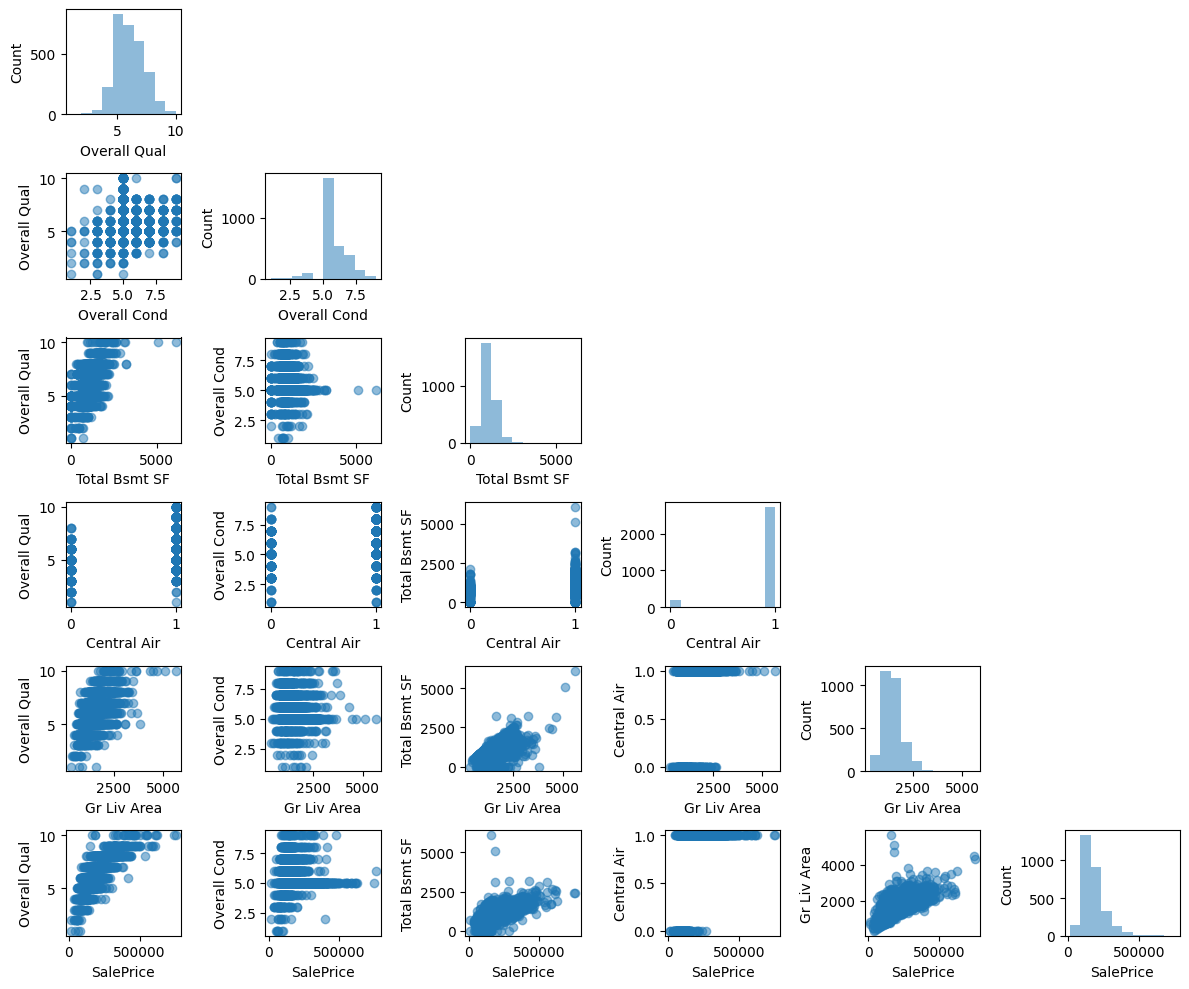

In [13]:
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df.values, figsize = (12, 10),
                  names = df.columns, alpha = 0.5)
plt.tight_layout()
plt.show()

Let's try around our geometric interpretation in this toy dataset. We want to understand how our geometric prospectiv works.

Let's use the Gr Living Area (size of the living area above ground in squeare feet) feature from the dataset as the explanatory variable and train a model that can predict SalePrice.

In [14]:
X = df[['Gr Liv Area']].values
y = df[['SalePrice']].values

X_c = add_dummy_feature(X)
# We cam do this with: X_c = np.hstack((X.shape[0],1), X)

beta = np.linalg.inv(X_c.T @ X_c) @ X_c.T @ y
beta

array([[13342.97866236],
       [  111.66625842]])

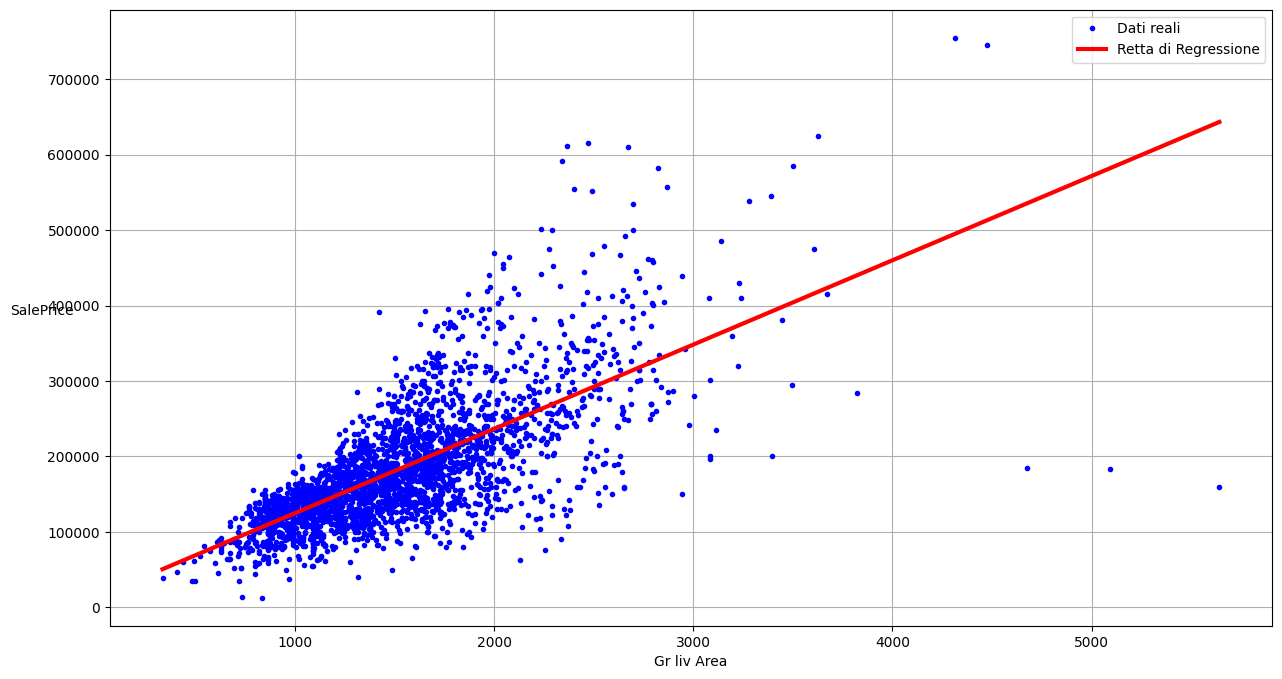

In [16]:
plt.figure(figsize = (15, 8))
plt.plot(X, y, "b.", label="Dati reali")

X_line = np.array([[X.min()], [X.max()]])
X_line_b = add_dummy_feature(X_line)
y_line = X_line_b @ beta

# Disegniamo la retta in rosso
plt.plot(X_line, y_line, "r-", linewidth=3, label="Retta di Regressione")

plt.xlabel("Gr liv Area")
plt.ylabel("SalePrice", rotation = 0)
plt.legend()
plt.grid(True)
plt.show()

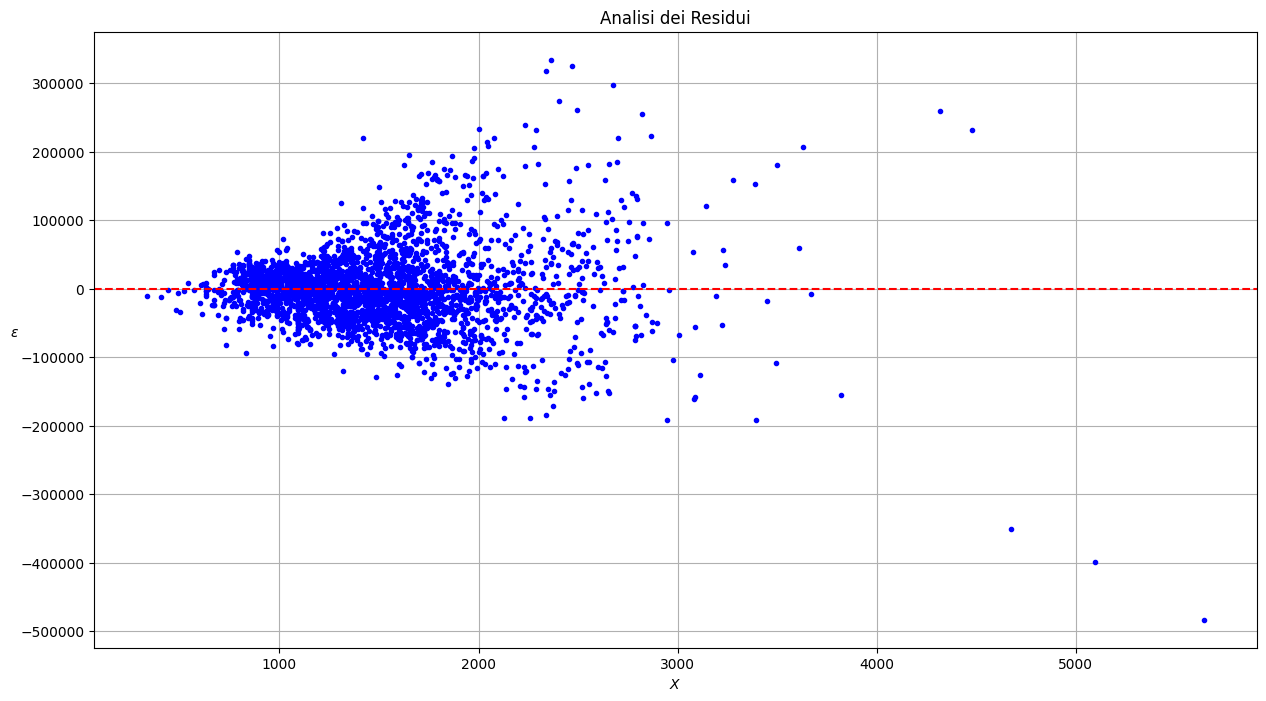

In [32]:
y_hat = X_c @ beta
errors = y - y_hat

plt.figure(figsize=(15, 8))
plt.plot(X, errors, "b.")
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("$X$")
plt.ylabel(r"$\varepsilon$", rotation=0)
plt.title("Analisi dei Residui")
plt.grid(True)
plt.show()

In [29]:
print(errors.shape)
print(X.shape)

(2929, 1)
(2929, 1)
